<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/Day14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
# import warnings
# warnings.filterwarnings("ignore")
# pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
import os
# print(os.getcwd())
# os.chdir('/content/drive/MyDrive/CDAC')
# os.getcwd()

**Bias^2 + variance + Irreduceable error**

Variance : when model is overly sensitive to training data

Underfitting(Scenario):

- Model is too simple
- High Bias and low variance

```
Aspect                   Underfitting            Overfitting
Bias                         High                    Low
Variance                     Low                     High
Training Error               High                  Very Low
Test Error                   High                    High
Model Complexity             Low                     High
```

# Simple Linear Regression:

Used when response is single and continuous and predector is single and continuous.

line equation: y = mx + c

- m = slope of the line (tangent of θ), θ is the angle made with x-axis.
- c = constant, it is value on y-intercept where c cuts y axis or c is value on y-axis when x=0

1st quadrant, tanθ = +ve
2nd quadrant, tanθ = -ve

# **Simple Regression(Ho) : Predictor (X) does not influence Response (Y)**
## m (Ho) : m = 0 , x does not influence y
## c (Ho) : c = 0 , c does not influence y

In [3]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='faithful')
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [5]:
# waiting is the predictor
# eruption is the response

scipy.stats.pearsonr(df['eruptions'], df['waiting'])

PearsonRResult(statistic=np.float64(0.9008111683218132), pvalue=np.float64(8.129958506615525e-100))

Text(0, 0.5, 'waiting')

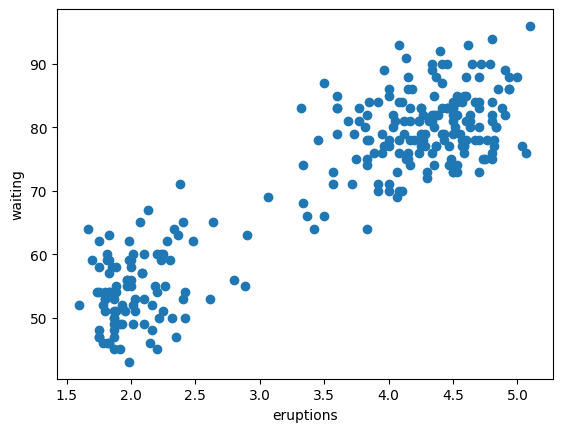

In [6]:
plt.scatter(df['eruptions'], df['waiting'])
plt.xlabel('eruptions')
plt.ylabel('waiting')

In [10]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions,test_size=0.3,random_state=20)
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [8]:
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (190,)
x_test shape: (82,)
y_train shape: (190,)
y_test shape: (82,)


In [11]:
x_train = sm.add_constant(x_train, prepend=True)
x_test = sm.add_constant(x_test, prepend=True)

In [12]:
x_train.head()

,const,waiting
182,1.0,83
248,1.0,67
50,1.0,75
209,1.0,83
200,1.0,60


## Steps
1. Null Hypothesis
2. p-value
3. what to do with p-value
4. Conclusion (Effect is there or not)
5. Effect

In [25]:
mod1 = sm.OLS(y_train, x_train).fit()
print(mod1.summary())

# R-squared(coefficient of determination) : It represents percentage of variation the data which is explained by the model.
# R-squared: 80.4% of variation is explained by the model.

# z = variance between sample / variance within sample
#   =  Explained / Unexplained
# Total = Explained + Unexplained

# erupt = 0.0782 x w - 2.08
# coeff of waiting (0.0782) is the increase in the response when the predictor waiting is increase by 1 unit.

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        06:55:20   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0814      0.203    -10.273      0.0

R-Square : Is calculated for Training Data

**Conclusion:**

Ho m(coeff of waiting) = 0

- Ho m=0, m(waiting) does influences y(eruptions),

- Ho c=0, c(intercept) does influence y(eruption)

In [24]:
# Model
mydata = pd.DataFrame([[80,1],[90,1],[100,1]], columns = x_train.columns)
mypreds = mod1.predict(mydata)
print(mypreds)

0   -166.436487
1   -187.250826
2   -208.065166
dtype: float64


In [27]:
y_preds = mod1.predict(x_train)
y_preds.head()

,0
182,4.411512
248,3.159859
50,3.785686
209,4.411512
200,2.612262


In [29]:
# Residuals (Error) = y_train - y_pred
residuals = y_train - y_preds
y_train.head()

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


Residuals (Error): 1.0613732115416497e-13


(array([ 5.,  9., 18., 30., 25., 36., 30., 20., 13.,  4.]),
 array([-1.25817472, -1.01204863, -0.76592254, -0.51979646, -0.27367037,
        -0.02754428,  0.21858181,  0.4647079 ,  0.71083398,  0.95696007,
         1.20308616]),
 <BarContainer object of 10 artists>)

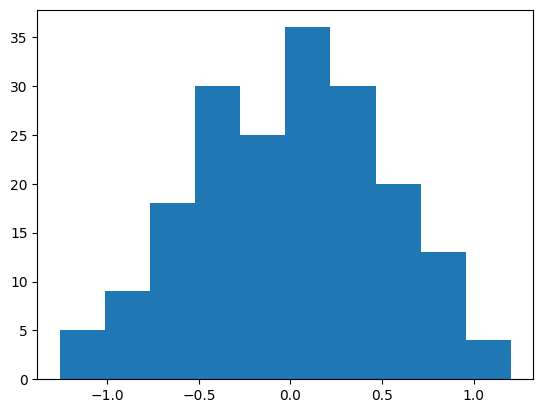

In [35]:
print(f'Residuals (Error): {sum(residuals)}')
plt.hist(residuals)

In [39]:
SSE = sum(residuals**2)
SSE   # sum squared error
# SSE is Unexplained Variation

# SST is sum square error total (total variation)
SST = sum((y_train - np.mean(y_train))**2)
SST

SSR = SST - SSE   # sum squared of Regression
SSR  # Explained Error

SSR/SST   # R-Squared Value
# Fraction of total variation explained by model. This ratio is the same as R^2.

F = ((SSR/(1)) / (SSE/(188)))
# number of values = 190
# Total DoF = 189
# DoF for Regression = 2 - 1 = 1
# DoF for error or residual = 189 - 1 = 188
F

771.0588750529831